In [1]:
!pip install -q wfdb neurokit2 scikit-learn imbalanced-learn seaborn plotly torch torchmetrics torchsummary wget


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 26.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import os, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wfdb
import ast
import glob
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              multilabel_confusion_matrix, f1_score,
                              precision_score, recall_score, roc_curve)
from sklearn.utils.class_weight import compute_sample_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchmetrics import AUROC, AveragePrecision, F1Score
from torchsummary import summary

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


Device: cpu
GPU: CPU only


In [3]:
import os, glob
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

DRIVE_ZIP_PATH  = "/content/drive/MyDrive/ptbxl.zip"
LOCAL_ZIP_PATH  = "/content/ptbxl.zip"
LOCAL_EXTRACT   = "/content/ptbxl/"

# ── Step 1: Download to Drive ONLY if not already there ──────────────────────
if not os.path.exists(DRIVE_ZIP_PATH):
    print("ZIP not found in Drive. Downloading PTB-XL (~1.8 GB)...")
    !wget -q --show-progress \
        -O "{DRIVE_ZIP_PATH}" \
        "https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"
    print("✅ Download complete. ZIP saved to Google Drive.")
else:
    print("✅ ZIP already exists in Drive. Skipping download.")

# ── Step 2: Copy from Drive to local Colab disk (fast) ───────────────────────
if not os.path.exists(LOCAL_ZIP_PATH):
    print("Copying ZIP from Drive to local disk...")
    !cp "{DRIVE_ZIP_PATH}" "{LOCAL_ZIP_PATH}"
    print("✅ Copy complete.")
else:
    print("✅ ZIP already on local disk. Skipping copy.")

# ── Step 3: Unzip locally ONLY if not already extracted ──────────────────────
os.makedirs(LOCAL_EXTRACT, exist_ok=True)

if not glob.glob('/content/ptbxl/ptb-xl*'):
    print("Extracting ZIP...")
    !unzip -q "{LOCAL_ZIP_PATH}" -d "{LOCAL_EXTRACT}"
    print("✅ Extraction complete.")
else:
    print("✅ Files already extracted. Skipping unzip.")

# ── Step 4: Locate dataset path ──────────────────────────────────────────────
ptbxl_path = glob.glob('/content/ptbxl/ptb-xl*')[0]
print(f"\n📁 Dataset path: {ptbxl_path}")

Mounted at /content/drive
✅ ZIP already exists in Drive. Skipping download.
Copying ZIP from Drive to local disk...
✅ Copy complete.
Extracting ZIP...
✅ Extraction complete.

📁 Dataset path: /content/ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [4]:
df = pd.read_csv(f'{ptbxl_path}/ptbxl_database.csv', index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

agg_full = pd.read_csv(f'{ptbxl_path}/scp_statements.csv', index_col=0)
agg_full = agg_full[agg_full.diagnostic == 1.0]

def aggregate_superclass(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_full.index:
            cls = agg_full.loc[key].diagnostic_class
            if pd.notna(cls):
                tmp.append(cls)
    return list(set(tmp))

df['diagnostic_superclass'] = df['scp_codes'].apply(aggregate_superclass)

df_labeled = df[df['diagnostic_superclass'].map(len) > 0].copy()
print(f"Total labeled records: {len(df_labeled)}")
print(f"Superclasses: {sorted(set(c for row in df_labeled['diagnostic_superclass'] for c in row))}")


Total labeled records: 21388
Superclasses: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


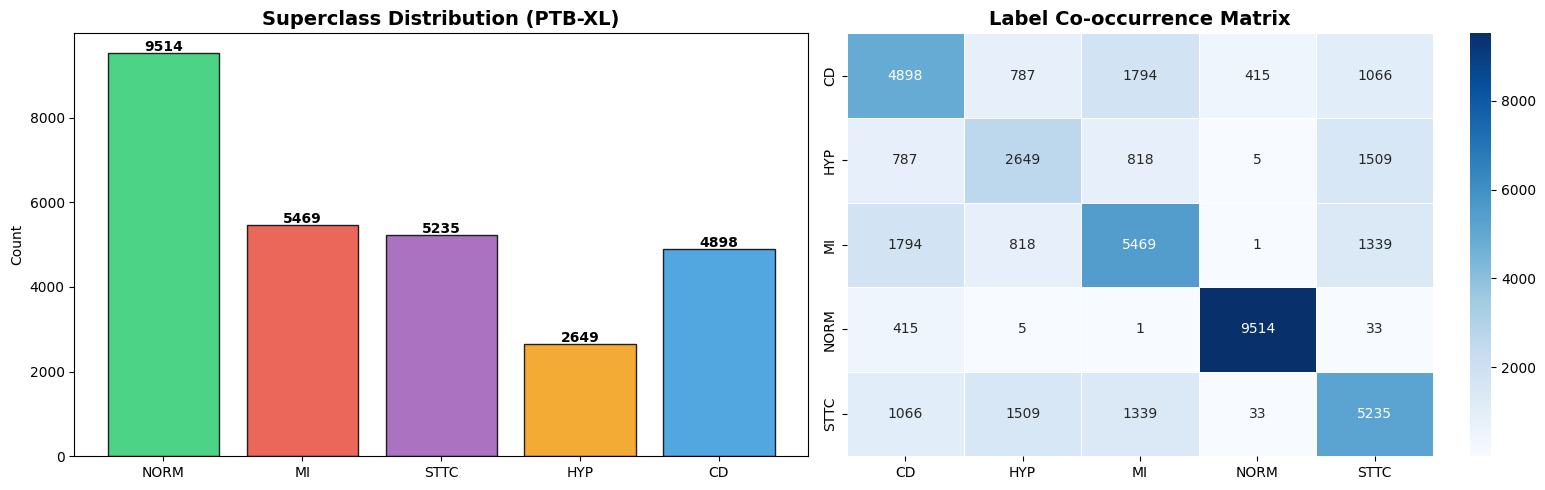


Class distribution:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
dtype: int64


In [5]:
from collections import Counter

all_labels = [label for row in df_labeled['diagnostic_superclass'] for label in row]
label_counts = Counter(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes = list(label_counts.keys())
counts = list(label_counts.values())
colors = ['#2ecc71' if c == 'NORM' else '#e74c3c' if c == 'MI'
          else '#3498db' if c == 'CD' else '#f39c12' if c == 'HYP'
          else '#9b59b6' for c in classes]

axes[0].bar(classes, counts, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Superclass Distribution (PTB-XL)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (c, v) in enumerate(zip(classes, counts)):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

mlb = MultiLabelBinarizer()
y_binary = mlb.fit_transform(df_labeled['diagnostic_superclass'])
co_occur = pd.DataFrame(y_binary, columns=mlb.classes_).T.dot(
    pd.DataFrame(y_binary, columns=mlb.classes_))
sns.heatmap(co_occur, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Label Co-occurrence Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nClass distribution:\n{pd.Series(label_counts).sort_values(ascending=False)}")


In [6]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(f'{path}/{f}') for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(f'{path}/{f}') for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

SAMPLING_RATE = 100
print("Loading waveforms (Lead I=0, Lead II=1, Lead III=2)...")

X_raw = load_raw_data(df_labeled, SAMPLING_RATE, ptbxl_path)
X_3lead = X_raw[:, :, :3]  # shape: (N, 1000, 3)
print(f"Raw waveform shape (3-lead): {X_3lead.shape}")
print(f"Lead order: Lead I, Lead II, Lead III")
print(f"Sampling rate: {SAMPLING_RATE} Hz, Duration: {X_3lead.shape[1]/SAMPLING_RATE}s")


Loading waveforms (Lead I=0, Lead II=1, Lead III=2)...
Raw waveform shape (3-lead): (21388, 1000, 3)
Lead order: Lead I, Lead II, Lead III
Sampling rate: 100 Hz, Duration: 10.0s


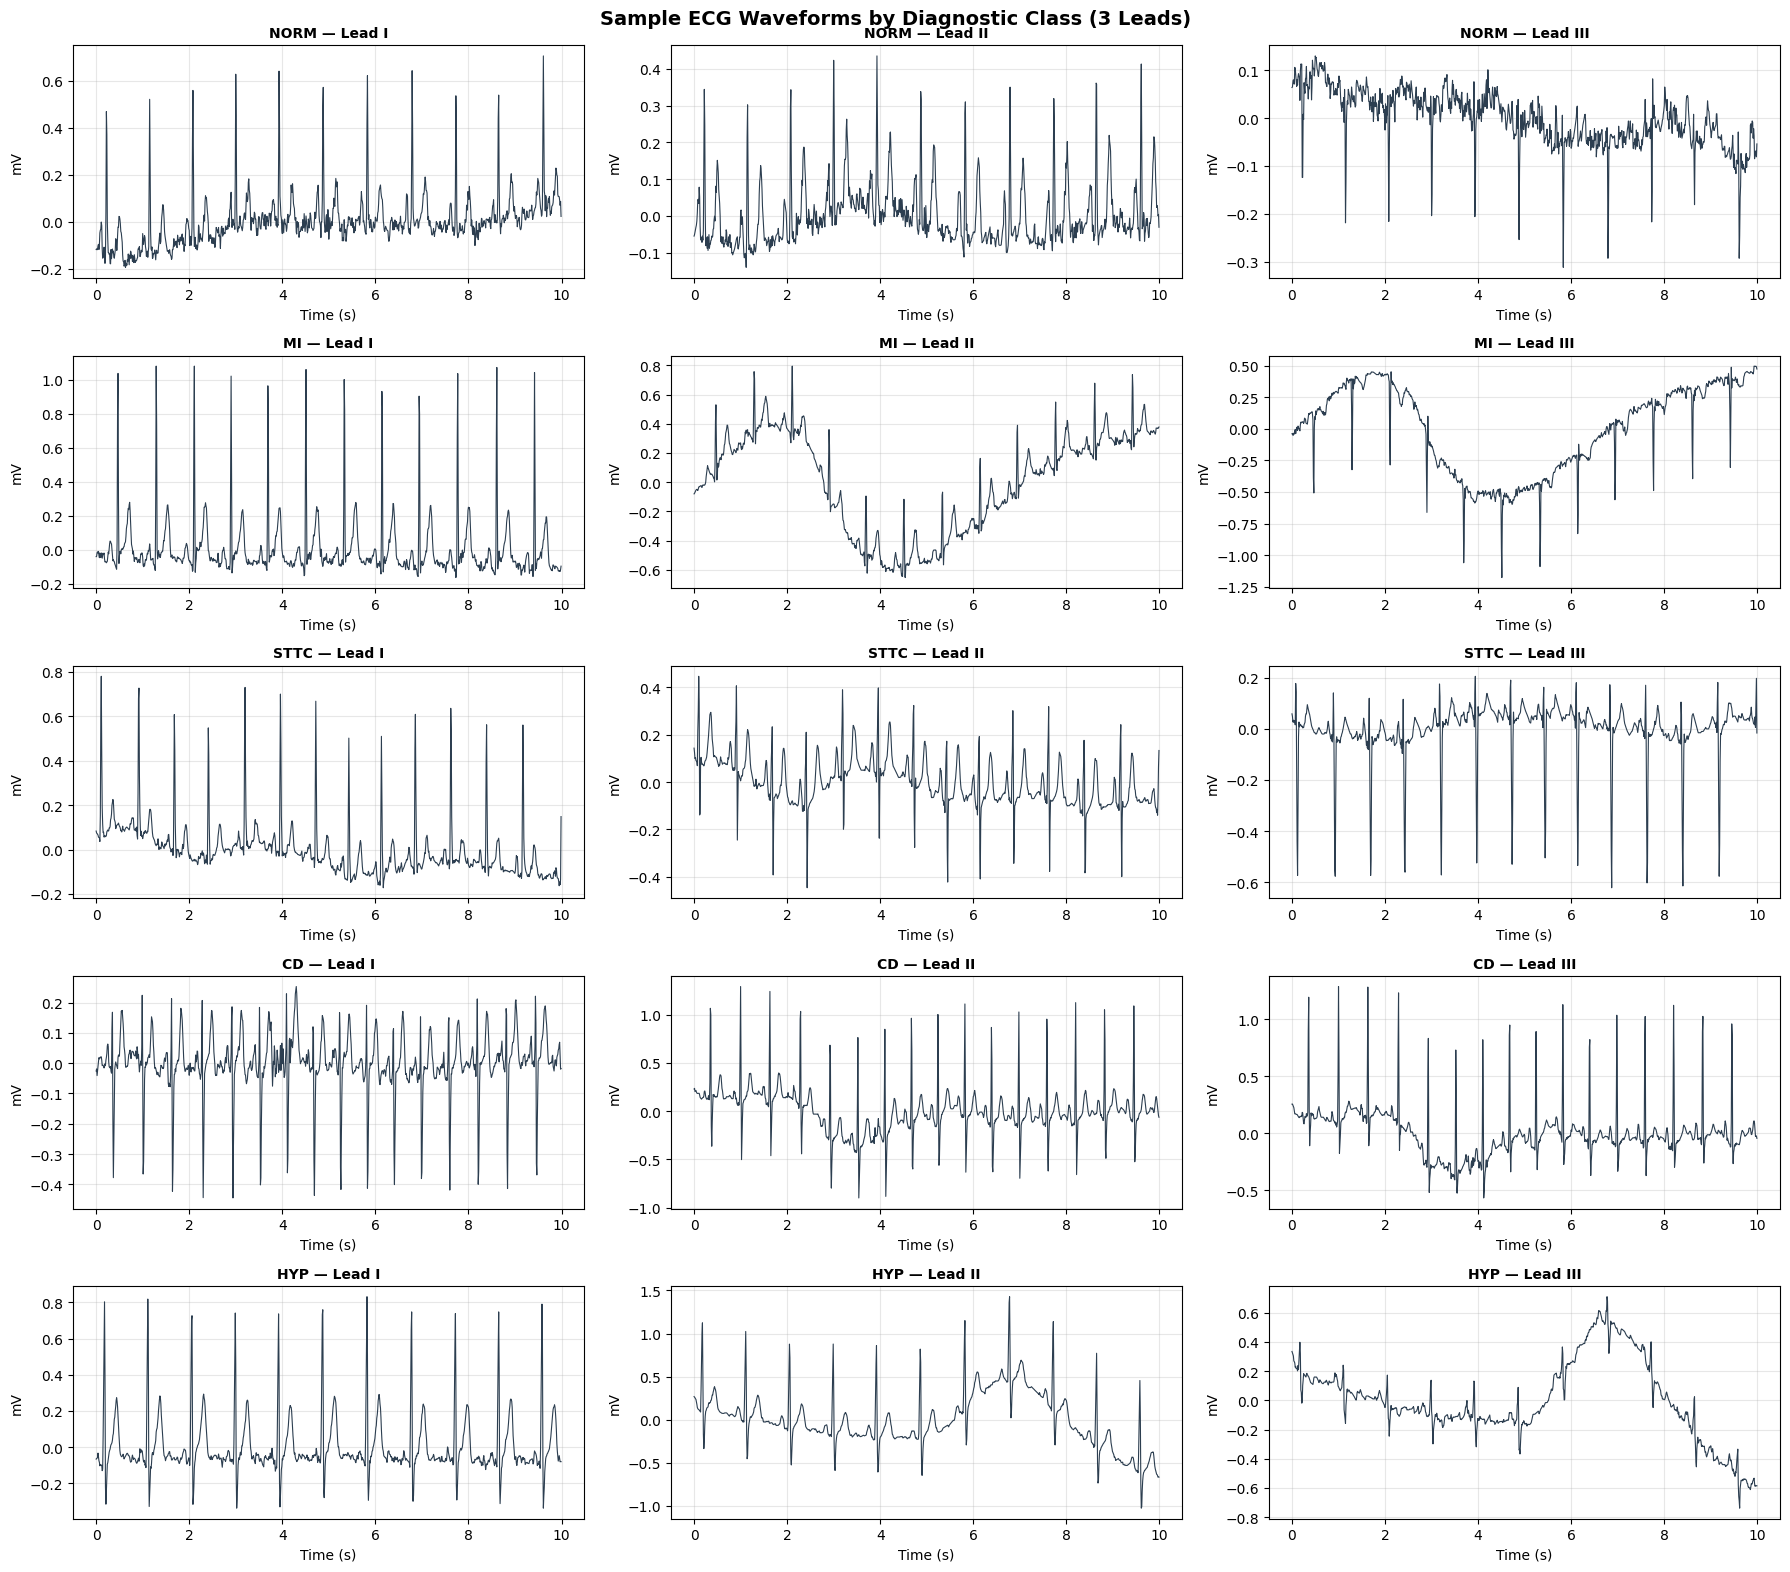

In [7]:
LEAD_NAMES = ['Lead I', 'Lead II', 'Lead III']
CLASS_EXAMPLES = {'NORM': None, 'MI': None, 'STTC': None, 'CD': None, 'HYP': None}

for idx, row in df_labeled.iterrows():
    for cls in CLASS_EXAMPLES:
        if cls in row['diagnostic_superclass'] and CLASS_EXAMPLES[cls] is None:
            CLASS_EXAMPLES[cls] = df_labeled.index.get_loc(idx)

fig, axes = plt.subplots(5, 3, figsize=(18, 16))
t = np.arange(1000) / SAMPLING_RATE

for row_idx, (cls, sample_idx) in enumerate(CLASS_EXAMPLES.items()):
    if sample_idx is None:
        continue
    for lead_idx in range(3):
        sig = X_3lead[sample_idx, :, lead_idx]
        axes[row_idx, lead_idx].plot(t, sig, linewidth=0.8, color='#2c3e50')
        axes[row_idx, lead_idx].set_title(f'{cls} — {LEAD_NAMES[lead_idx]}',
                                          fontsize=10, fontweight='bold')
        axes[row_idx, lead_idx].set_xlabel('Time (s)')
        axes[row_idx, lead_idx].set_ylabel('mV')
        axes[row_idx, lead_idx].grid(True, alpha=0.3)

plt.suptitle('Sample ECG Waveforms by Diagnostic Class (3 Leads)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_raw_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()


=== Per-Lead Signal Statistics ===
    Lead  Mean (mV)  Std (mV)  Min (mV)  Max (mV)  Skewness   Kurtosis  SNR (dB)
  Lead I  -0.001610  0.158635    -7.455     4.398  1.014317  96.884249 -5.522851
 Lead II  -0.001327  0.159937    -5.856     5.576  2.157761  25.880063 -4.746438
Lead III   0.000283  0.159595    -4.656     7.491  0.190657 105.293736 -5.872940


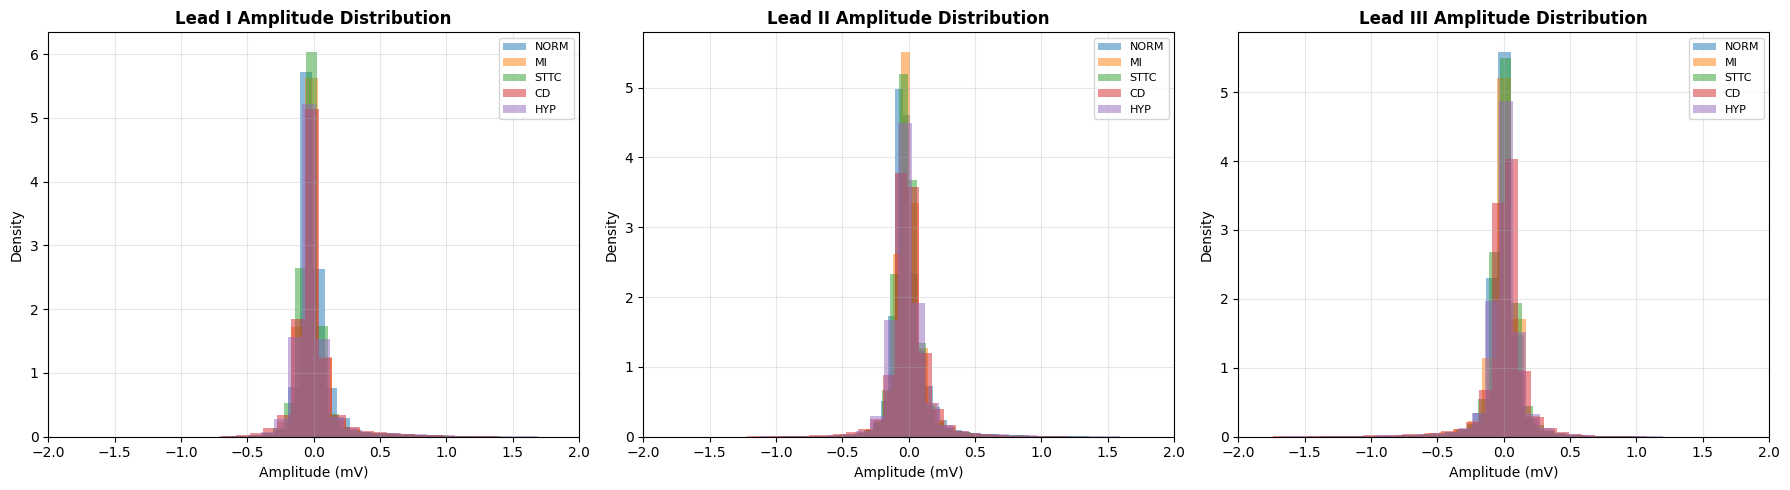

In [8]:
stats_data = []
for lead_idx, lead_name in enumerate(LEAD_NAMES):
    lead_data = X_3lead[:, :, lead_idx].flatten()
    stats_data.append({
        'Lead': lead_name,
        'Mean (mV)': np.mean(lead_data),
        'Std (mV)': np.std(lead_data),
        'Min (mV)': np.min(lead_data),
        'Max (mV)': np.max(lead_data),
        'Skewness': skew(lead_data),
        'Kurtosis': kurtosis(lead_data),
        'SNR (dB)': 20 * np.log10(np.mean(np.abs(lead_data)) / (np.std(lead_data) + 1e-8))
    })

stats_df = pd.DataFrame(stats_data)
print("=== Per-Lead Signal Statistics ===")
print(stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for lead_idx, (ax, lead_name) in enumerate(zip(axes, LEAD_NAMES)):
    for cls in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
        mask = df_labeled['diagnostic_superclass'].apply(lambda x: cls in x)
        lead_data = X_3lead[mask.values, :, lead_idx].flatten()
        if len(lead_data) > 0:
            ax.hist(lead_data, bins=100, alpha=0.5, label=cls, density=True)
    ax.set_title(f'{lead_name} Amplitude Distribution', fontweight='bold')
    ax.set_xlabel('Amplitude (mV)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(-2, 2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_amplitude_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


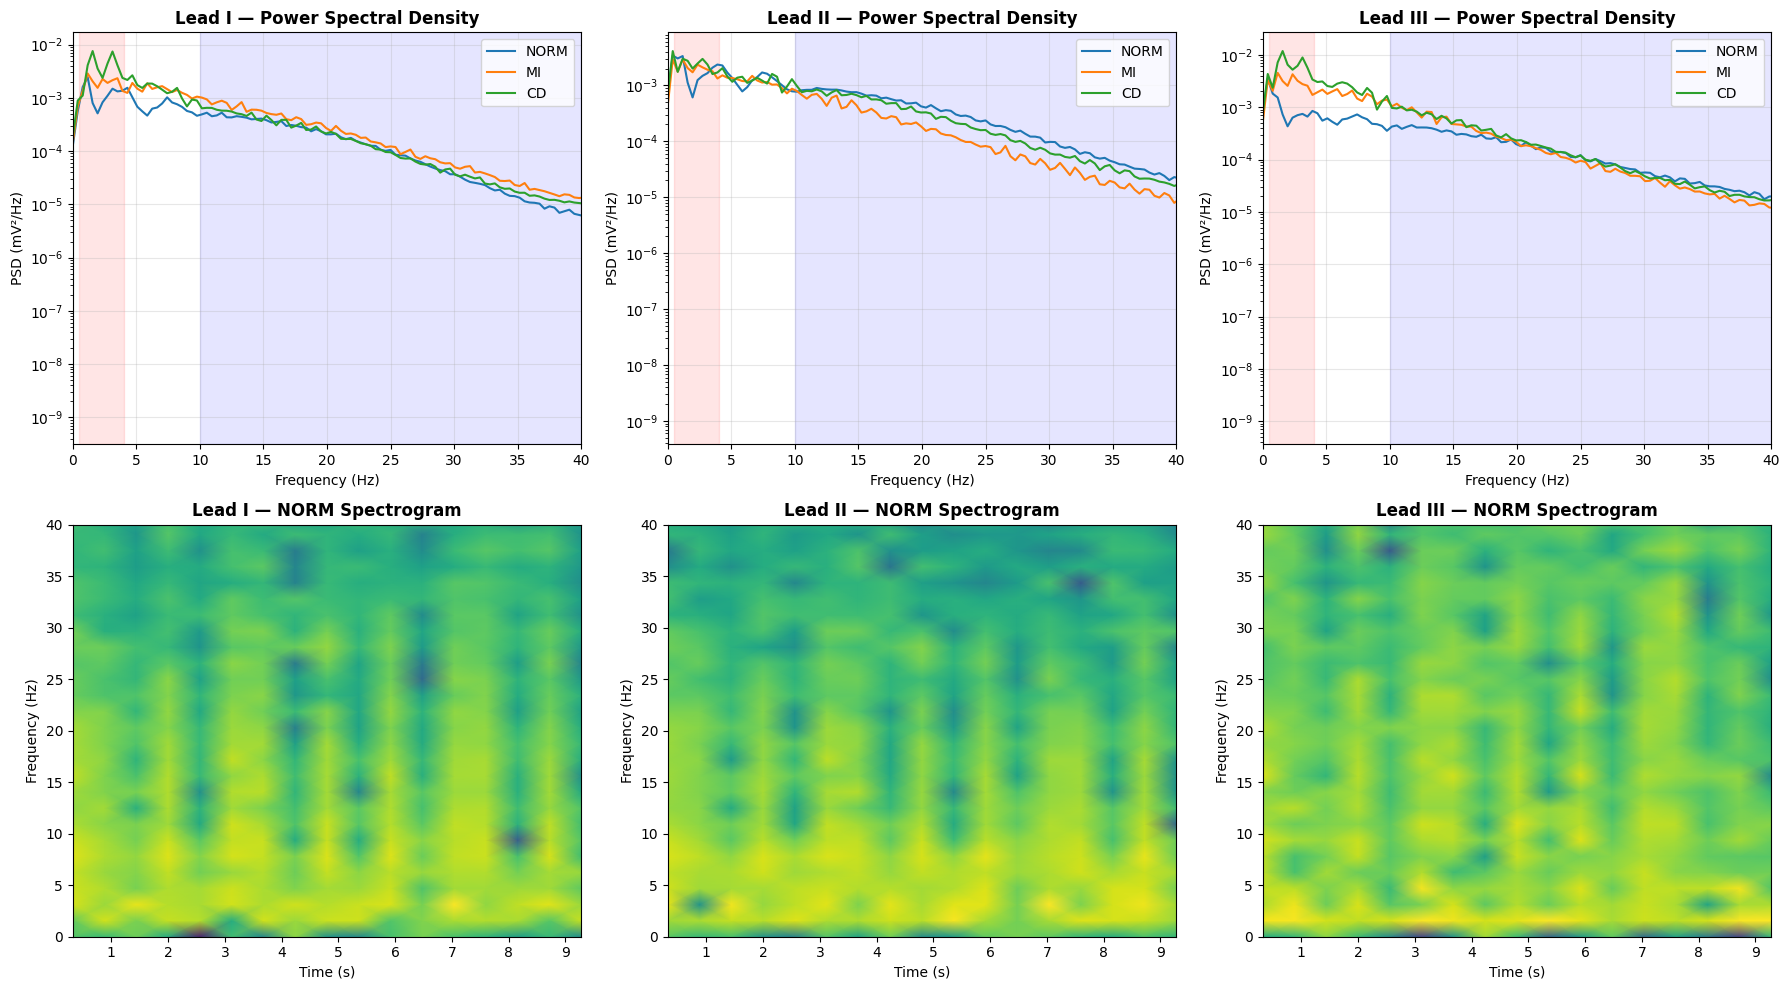

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for lead_idx, lead_name in enumerate(LEAD_NAMES):
    ax = axes[0, lead_idx]
    for cls in ['NORM', 'MI', 'CD']:
        mask = df_labeled['diagnostic_superclass'].apply(lambda x: cls in x)
        samples = X_3lead[mask.values, :, lead_idx][:50]
        psds = []
        for s in samples:
            f, psd = scipy_signal.welch(s, fs=SAMPLING_RATE, nperseg=256)
            psds.append(psd)
        mean_psd = np.mean(psds, axis=0)
        ax.semilogy(f, mean_psd, label=cls, linewidth=1.5)
    ax.set_title(f'{lead_name} — Power Spectral Density', fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (mV²/Hz)')
    ax.set_xlim(0, 40)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvspan(0.5, 4, alpha=0.1, color='red')
    ax.axvspan(10, 40, alpha=0.1, color='blue')

    ax2 = axes[1, lead_idx]
    norm_idx = next(i for i, row in enumerate(df_labeled['diagnostic_superclass'].values) if 'NORM' in row)
    sig = X_3lead[norm_idx, :, lead_idx]
    f_spec, t_spec, Sxx = scipy_signal.spectrogram(sig, fs=SAMPLING_RATE, nperseg=64)
    ax2.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
    ax2.set_title(f'{lead_name} — NORM Spectrogram', fontweight='bold')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Frequency (Hz)')
    ax2.set_ylim(0, 40)

plt.tight_layout()
plt.savefig('eda_frequency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


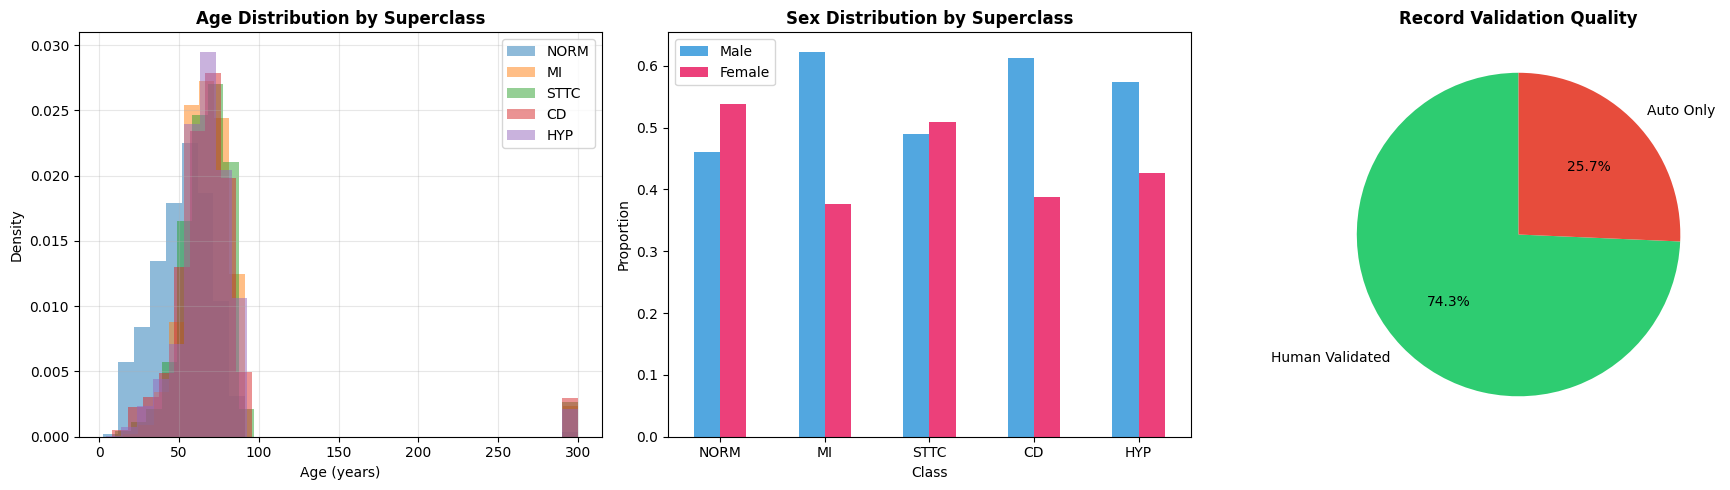


Age stats:
count    21388.000000
mean        62.608753
std         32.235489
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
    mask = df_labeled['diagnostic_superclass'].apply(lambda x: cls in x)
    ages = df_labeled[mask]['age'].dropna()
    axes[0].hist(ages, bins=30, alpha=0.5, label=cls, density=True)
axes[0].set_title('Age Distribution by Superclass', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sex_class = {}
for cls in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
    mask = df_labeled['diagnostic_superclass'].apply(lambda x: cls in x)
    sex_dist = df_labeled[mask]['sex'].value_counts(normalize=True)
    sex_class[cls] = sex_dist

sex_df = pd.DataFrame(sex_class).T.fillna(0)
sex_df.columns = ['Male', 'Female']
sex_df.plot(kind='bar', ax=axes[1], color=['#3498db', '#e91e63'], alpha=0.85)
axes[1].set_title('Sex Distribution by Superclass', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Proportion')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)

quality_counts = df_labeled['validated_by_human'].value_counts()
axes[2].pie(quality_counts.values,
            labels=['Human Validated', 'Auto Only'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[2].set_title('Record Validation Quality', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAge stats:\n{df_labeled['age'].describe()}")


Preprocessing ECG signals (bandpass 0.5–40 Hz + notch 50 Hz + z-score)...
Processed shape: (21388, 1000, 3)


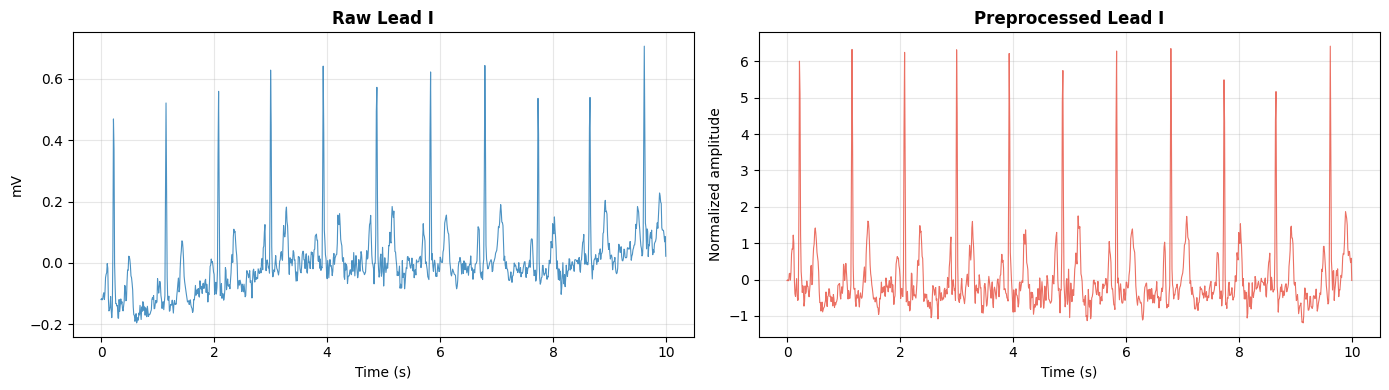

In [11]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    nyq = 0.5 * fs
    b, a = scipy_signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return scipy_signal.filtfilt(b, a, signal, axis=0)

def notch_filter(signal, freq=50.0, fs=100, Q=30):
    b, a = scipy_signal.iirnotch(freq / (fs / 2), Q)
    return scipy_signal.filtfilt(b, a, signal, axis=0)

def normalize_signal(signal):
    mean = signal.mean(axis=0, keepdims=True)
    std = signal.std(axis=0, keepdims=True) + 1e-8
    return (signal - mean) / std

def preprocess_ecg(X, fs=100):
    X_processed = np.zeros_like(X)
    for i in range(len(X)):
        sig = X[i]
        sig = bandpass_filter(sig, lowcut=0.5, highcut=40.0, fs=fs)
        sig = notch_filter(sig, freq=50.0, fs=fs)
        sig = normalize_signal(sig)
        X_processed[i] = sig
    return X_processed

print("Preprocessing ECG signals (bandpass 0.5–40 Hz + notch 50 Hz + z-score)...")
X_processed = preprocess_ecg(X_3lead, fs=SAMPLING_RATE)
print(f"Processed shape: {X_processed.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sample_idx = 0
t = np.arange(1000) / SAMPLING_RATE

axes[0].plot(t, X_3lead[sample_idx, :, 0], linewidth=0.8, label='Raw', alpha=0.8)
axes[0].set_title('Raw Lead I', fontweight='bold')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('mV')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, X_processed[sample_idx, :, 0], linewidth=0.8,
             label='Filtered', color='#e74c3c', alpha=0.8)
axes[1].set_title('Preprocessed Lead I', fontweight='bold')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Normalized amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
mlb = MultiLabelBinarizer(classes=['NORM', 'MI', 'STTC', 'CD', 'HYP'])
y = mlb.fit_transform(df_labeled['diagnostic_superclass'])
print(f"Label shape: {y.shape}")
print(f"Classes: {mlb.classes_}")
print(f"Multi-label records: {(y.sum(axis=1) > 1).sum()}")

test_mask = df_labeled['strat_fold'].isin([9, 10])
val_mask = df_labeled['strat_fold'] == 8
train_mask = ~(test_mask | val_mask)

X_train = X_processed[train_mask.values]
X_val   = X_processed[val_mask.values]
X_test  = X_processed[test_mask.values]
y_train = y[train_mask.values]
y_val   = y[val_mask.values]
y_test  = y[test_mask.values]

print(f"\nSplit sizes:")
print(f"  Train: {X_train.shape[0]} ({X_train.shape[0]/len(X_processed)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X_processed)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X_processed)*100:.1f}%)")

for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n{split_name} class counts:")
    for cls, count in zip(mlb.classes_, y_split.sum(axis=0)):
        print(f"  {cls}: {count}")


Label shape: (21388, 5)
Classes: ['NORM' 'MI' 'STTC' 'CD' 'HYP']
Multi-label records: 5144

Split sizes:
  Train: 14955 (69.9%)
  Val:   2129 (10.0%)
  Test:  4304 (20.1%)

Train class counts:
  NORM: 6664
  MI: 3841
  STTC: 3672
  CD: 3415
  HYP: 1851

Val class counts:
  NORM: 932
  MI: 538
  STTC: 514
  CD: 492
  HYP: 268

Test class counts:
  NORM: 1918
  MI: 1090
  STTC: 1049
  CD: 991
  HYP: 530


In [13]:
class ECGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X.transpose(0, 2, 1))  # (N, 3, 1000)
        self.y = torch.FloatTensor(y)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.augment:
            if np.random.rand() < 0.3:
                x = x + torch.randn_like(x) * 0.02
            if np.random.rand() < 0.3:
                scale = 0.9 + np.random.rand() * 0.2
                x = x * scale
            if np.random.rand() < 0.2:
                shift = np.random.randint(-50, 50)
                x = torch.roll(x, shift, dims=1)
        return x, y

pos_weight = torch.FloatTensor(
    (y_train.shape[0] - y_train.sum(0)) / (y_train.sum(0) + 1e-8)
).to(device)

train_dataset = ECGDataset(X_train, y_train, augment=True)
val_dataset   = ECGDataset(X_val,   y_val,   augment=False)
test_dataset  = ECGDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Input tensor shape: {next(iter(train_loader))[0].shape}")


Train batches: 234
Input tensor shape: torch.Size([64, 3, 1000])


In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, stride=1, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=kernel // 2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1, stride=stride) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.shortcut(x)


class ECG_CNN(nn.Module):
    def __init__(self, n_leads=3, n_classes=5):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(n_leads, 32, kernel=7),
            nn.MaxPool1d(2),           # → (32, 500)
            ConvBlock(32, 64, kernel=5),
            nn.MaxPool1d(2),           # → (64, 250)
            ConvBlock(64, 128, kernel=5),
            nn.MaxPool1d(2),           # → (128, 125)
            ConvBlock(128, 256, kernel=3),
            nn.MaxPool1d(2),           # → (256, 62)
            ConvBlock(256, 256, kernel=3),
            nn.AdaptiveAvgPool1d(1),   # → (256, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


model_cnn = ECG_CNN(n_leads=3, n_classes=5).to(device)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"CNN parameters: {total_params:,}")
summary(model_cnn, (3, 1000))


CNN parameters: 929,637
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 32, 1000]             672
       BatchNorm1d-2             [-1, 32, 1000]              64
              ReLU-3             [-1, 32, 1000]               0
           Dropout-4             [-1, 32, 1000]               0
            Conv1d-5             [-1, 32, 1000]           7,168
       BatchNorm1d-6             [-1, 32, 1000]              64
              ReLU-7             [-1, 32, 1000]               0
            Conv1d-8             [-1, 32, 1000]             128
         ConvBlock-9             [-1, 32, 1000]               0
        MaxPool1d-10              [-1, 32, 500]               0
           Conv1d-11              [-1, 64, 500]          10,240
      BatchNorm1d-12              [-1, 64, 500]             128
             ReLU-13              [-1, 64, 500]               0
          Dropo

In [15]:
class ECG_CNN_BiLSTM(nn.Module):
    def __init__(self, n_leads=3, n_classes=5, lstm_hidden=128, lstm_layers=2):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(n_leads, 32, kernel=7),
            nn.MaxPool1d(2),           # → (32, 500)
            ConvBlock(32, 64, kernel=5),
            nn.MaxPool1d(2),           # → (64, 250)
            ConvBlock(64, 128, kernel=5),
            nn.MaxPool1d(2),           # → (128, 125)
        )
        # After CNN: (B, 128, 125) → permute to (B, 125, 128) for LSTM
        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )
        self.attention = nn.Linear(lstm_hidden * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        feat = self.cnn(x)                        # (B, 128, 125)
        feat = feat.permute(0, 2, 1)              # (B, 125, 128)
        lstm_out, _ = self.bilstm(feat)           # (B, 125, 256)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # (B, 125, 1)
        context = (attn_weights * lstm_out).sum(dim=1)                 # (B, 256)
        return self.classifier(context)


model_bilstm = ECG_CNN_BiLSTM(n_leads=3, n_classes=5).to(device)
print(f"CNN-BiLSTM parameters: {sum(p.numel() for p in model_bilstm.parameters()):,}")


CNN-BiLSTM parameters: 866,150


In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class ECG_Transformer(nn.Module):
    def __init__(self, n_leads=3, n_classes=5, d_model=128, nhead=8,
                 num_layers=4, dropout=0.1):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(n_leads, 32, kernel=7),
            nn.MaxPool1d(2),                      # → (32, 500)
            ConvBlock(32, 64, kernel=5),
            nn.MaxPool1d(2),                      # → (64, 250)
            ConvBlock(64, d_model, kernel=5),
            nn.MaxPool1d(2),                      # → (d_model, 125)
        )
        self.pos_enc = PositionalEncoding(d_model, max_len=256)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        feat = self.cnn(x)                              # (B, d_model, 125)
        feat = feat.permute(0, 2, 1)                   # (B, 125, d_model)
        feat = self.pos_enc(feat)
        cls = self.cls_token.expand(feat.size(0), -1, -1)
        feat = torch.cat([cls, feat], dim=1)           # (B, 126, d_model)
        out = self.transformer(feat)                   # (B, 126, d_model)
        return self.classifier(out[:, 0])              # CLS token


model_transformer = ECG_Transformer(n_leads=3, n_classes=5).to(device)
print(f"CNN-Transformer parameters: {sum(p.numel() for p in model_transformer.parameters()):,}")


CNN-Transformer parameters: 711,525


In [17]:
def train_model(model, model_name, train_loader, val_loader, epochs=50, lr=1e-3, patience=10):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = {'train_loss': [], 'val_loss': [], 'val_auroc': [], 'val_f1': []}
    best_val_auroc = 0
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validate ---
        model.eval()
        val_losses, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())
                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.append(probs)
                all_labels.append(y_batch.cpu().numpy())

        all_probs  = np.vstack(all_probs)
        all_labels = np.vstack(all_labels)
        val_auroc  = roc_auc_score(all_labels, all_probs, average='macro')
        val_f1     = f1_score(all_labels, (all_probs > 0.5).astype(int), average='macro', zero_division=0)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['val_auroc'].append(val_auroc)
        history['val_f1'].append(val_f1)
        scheduler.step()

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{model_name}.pt')
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {np.mean(train_losses):.4f} | "
                  f"Val Loss: {np.mean(val_losses):.4f} | "
                  f"Val AUROC: {val_auroc:.4f} | "
                  f"Val F1: {val_f1:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(f'best_{model_name}.pt'))
    return model, history


In [18]:
print("=" * 60)
print("Training Model 1: CNN")
print("=" * 60)
model_cnn, history_cnn = train_model(model_cnn, 'cnn', train_loader, val_loader, epochs=50)

print("\n" + "=" * 60)
print("Training Model 2: CNN-BiLSTM")
print("=" * 60)
model_bilstm, history_bilstm = train_model(model_bilstm, 'bilstm', train_loader, val_loader, epochs=50)

print("\n" + "=" * 60)
print("Training Model 3: CNN-Transformer")
print("=" * 60)
model_transformer, history_transformer = train_model(model_transformer, 'transformer', train_loader, val_loader, epochs=50)


Training Model 1: CNN


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
histories = {'CNN': history_cnn, 'CNN-BiLSTM': history_bilstm, 'CNN-Transformer': history_transformer}
colors = {'CNN': '#e74c3c', 'CNN-BiLSTM': '#3498db', 'CNN-Transformer': '#2ecc71'}

for ax_idx, metric in enumerate(['val_loss', 'val_auroc', 'val_f1']):
    for name, hist in histories.items():
        axes[ax_idx].plot(hist[metric], label=name, color=colors[name], linewidth=2)
    axes[ax_idx].set_title(metric.replace('_', ' ').title(), fontweight='bold')
    axes[ax_idx].set_xlabel('Epoch')
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)

plt.suptitle('Training History — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
def evaluate_model(model, loader, model_name, classes):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.numpy())

    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    preds  = (probs > 0.5).astype(int)

    metrics = {}
    for i, cls in enumerate(classes):
        metrics[cls] = {
            'AUROC':       roc_auc_score(labels[:, i], probs[:, i]),
            'AUPRC':       average_precision_score(labels[:, i], probs[:, i]),
            'F1':          f1_score(labels[:, i], preds[:, i], zero_division=0),
            'Precision':   precision_score(labels[:, i], preds[:, i], zero_division=0),
            'Recall':      recall_score(labels[:, i], preds[:, i], zero_division=0),
            'Specificity': recall_score(1 - labels[:, i], 1 - preds[:, i], zero_division=0),
        }

    metrics_df  = pd.DataFrame(metrics).T
    macro_auroc = roc_auc_score(labels, probs, average='macro')
    macro_f1    = f1_score(labels, preds, average='macro', zero_division=0)

    print(f"Model: {model_name}")
    print("=" * 50)
    print(f"Macro AUROC: {macro_auroc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"\nPer-class metrics:")
    print(metrics_df.round(4).to_string())
    return probs, labels, preds, metrics_df, macro_auroc


results = {}
for model_obj, model_name in [(model_cnn, 'CNN'),
                               (model_bilstm, 'CNN-BiLSTM'),
                               (model_transformer, 'CNN-Transformer')]:
    probs, labels, preds, metrics_df, macro_auroc = evaluate_model(
        model_obj, test_loader, model_name, mlb.classes_)
    results[model_name] = {
        'probs': probs, 'labels': labels, 'preds': preds,
        'metrics': metrics_df, 'macro_auroc': macro_auroc
    }


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
model_colors = {'CNN': '#e74c3c', 'CNN-BiLSTM': '#3498db', 'CNN-Transformer': '#2ecc71'}

for cls_idx, cls in enumerate(mlb.classes_):
    ax = axes[0, cls_idx]
    for model_name, res in results.items():
        fpr, tpr, _ = roc_curve(res['labels'][:, cls_idx], res['probs'][:, cls_idx])
        auc = res['metrics'].loc[cls, 'AUROC']
        ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})",
                color=model_colors[model_name], linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f'ROC — {cls}', fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

best_model_name = max(results, key=lambda k: results[k]['macro_auroc'])
best_results = results[best_model_name]

for cls_idx, cls in enumerate(mlb.classes_):
    ax_cm = axes[1, cls_idx]
    cm = confusion_matrix(best_results['labels'][:, cls_idx],
                          best_results['preds'][:, cls_idx])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax_cm.set_title(f'{best_model_name}\nConfusion — {cls}', fontweight='bold', fontsize=9)
    ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')

plt.tight_layout()
plt.savefig('roc_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
summary_data = []
for model_name, res in results.items():
    row = {'Model': model_name, 'Macro AUROC': res['macro_auroc']}
    for cls in mlb.classes_:
        row[f'{cls}_AUROC'] = res['metrics'].loc[cls, 'AUROC']
        row[f'{cls}_F1']    = res['metrics'].loc[cls, 'F1']
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("=== MODEL COMPARISON ===")
print(summary_df.to_string(index=False))

categories = list(mlb.classes_) + [list(mlb.classes_)[0]]
fig = go.Figure()
for model_name, res in results.items():
    values = [res['metrics'].loc[cls, 'AUROC'] for cls in mlb.classes_]
    values += [values[0]]
    fig.add_trace(go.Scatterpolar(
        r=values, theta=categories, fill='toself',
        name=model_name, opacity=0.6))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Per-Class AUROC — All Models',
    font=dict(size=12)
)
fig.write_image('radar_model_comparison.png')
fig.show()


In [ ]:
from datetime import datetime

best_model_name = max(results, key=lambda k: results[k]['macro_auroc'])
best_model_obj = {'CNN': model_cnn, 'CNN-BiLSTM': model_bilstm,
                  'CNN-Transformer': model_transformer}[best_model_name]

print(f"Best model: {best_model_name} (Macro AUROC: {results[best_model_name]['macro_auroc']:.4f})")

torch.save({
    'state_dict': best_model_obj.state_dict(),
    'model_name': best_model_name,
    'classes': list(mlb.classes_),
    'n_leads': 3,
    'lead_names': ['Lead I', 'Lead II', 'Lead III'],
    'sampling_rate': SAMPLING_RATE,
    'input_shape': '(3, 1000)',
    'macro_auroc': results[best_model_name]['macro_auroc'],
    'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}, 'medverse_ecg_arrhythmia.pt')

import json
with open('medverse_ecg_classes.json', 'w') as f:
    json.dump({
        'classes': list(mlb.classes_),
        'class_descriptions': {
            'NORM': 'Normal sinus rhythm',
            'MI':   'Myocardial Infarction',
            'STTC': 'ST/T-wave Change',
            'CD':   'Conduction Disturbance',
            'HYP':  'Hypertrophy',
        },
        'threshold': 0.5,
        'input_leads': ['Lead I', 'Lead II', 'Lead III'],
        'sampling_rate': SAMPLING_RATE,
        'signal_duration_s': 10,
    }, f, indent=2)

print("Files saved: medverse_ecg_arrhythmia.pt, medverse_ecg_classes.json")


In [ ]:
def predict_ecg(model, lead1, lead2, lead3, classes, threshold=0.5):
    sig = np.stack([lead1, lead2, lead3], axis=-1)  # (1000, 3)
    sig = bandpass_filter(sig)
    sig = notch_filter(sig)
    sig = normalize_signal(sig)
    x = torch.FloatTensor(sig.transpose(1, 0)).unsqueeze(0).to(device)  # (1, 3, 1000)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x)).cpu().numpy()[0]
    output = {cls: float(prob) for cls, prob in zip(classes, probs)}
    output['prediction'] = [cls for cls, prob in zip(classes, probs) if prob > threshold]
    if not output['prediction']:
        output['prediction'] = [max(zip(classes, probs), key=lambda kv: kv[1])[0]]
    return output

# Test on a real sample
test_sample = X_test[0]
result = predict_ecg(
    best_model_obj,
    test_sample[:, 0], test_sample[:, 1], test_sample[:, 2],
    classes=list(mlb.classes_)
)

true_labels = [mlb.classes_[i] for i in np.where(y_test[0])[0]]
print(f"True labels:  {true_labels}")
print(f"Predicted:    {result['prediction']}")
print("\nClass probabilities:")
for cls, prob in result.items():
    if isinstance(prob, float):
        bar = '█' * int(prob * 20)
        print(f"  {cls:6s}: {prob:.3f}  {bar}")
